# Модуль 3. Ансамбли: сила многих слабых моделей

**Интерактивная версия:** `lessons/lesson_3/web/index.html`

1. Дисперсия среднего коррелированных моделей: формула и симуляция.
2. Бэггинг глубоких деревьев против бустинга пней.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import matplotlib.pyplot as plt
from gbcourse import datasets, BaggingTrees, GBRegressor
from gbcourse.metrics import mse
from gbcourse.plotting import use_course_style

use_course_style()

## 1. Мудрость толпы: $\mathrm{Var} = \rho\sigma^2 + (1-\rho)\sigma^2/B$

Сгенерируем $B$ коррелированных «ошибок моделей»: $e_b = \sqrt{\rho}\,z + \sqrt{1-\rho}\,\varepsilon_b$.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


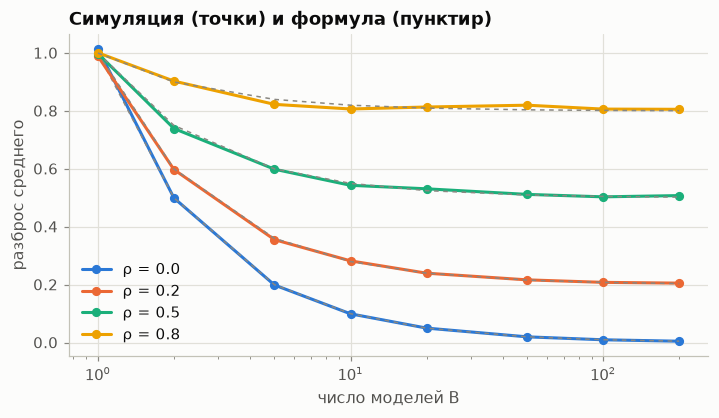

In [2]:
rng = np.random.default_rng(0)
Bs = np.array([1, 2, 5, 10, 20, 50, 100, 200])
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for rho in (0.0, 0.2, 0.5, 0.8):
    sim = []
    for B in Bs:
        z = rng.normal(size=(20000, 1))
        eps = rng.normal(size=(20000, B))
        sim.append((np.sqrt(rho) * z + np.sqrt(1 - rho) * eps).mean(axis=1).var())
    ax.plot(Bs, sim, marker="o", label=f"ρ = {rho}")
    ax.plot(Bs, rho + (1 - rho) / Bs, color="#898781", lw=1, ls=(0, (3, 3)))
ax.set_xscale("log")
ax.set(xlabel="число моделей B", ylabel="разброс среднего", title="Симуляция (точки) и формула (пунктир)")
ax.legend()
plt.show()

## 2. Бэггинг против бустинга

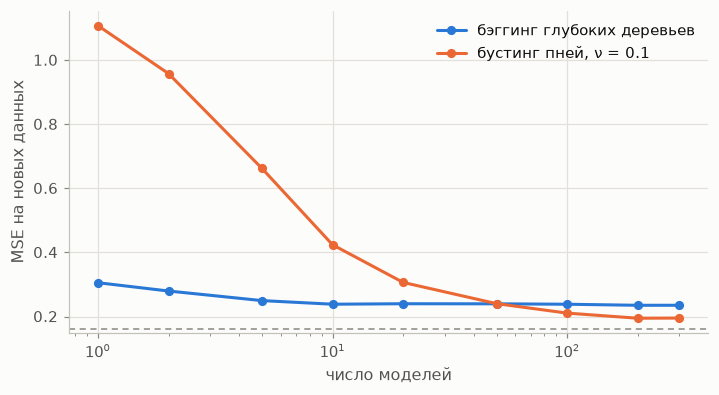

In [3]:
X, y = datasets.regression_1d(kind="wave", n=80, noise=0.4, seed=21)
X_te, y_te = datasets.regression_1d(kind="wave", n=2000, noise=0.4, seed=22)
bag = BaggingTrees(n_estimators=300, max_depth=None, seed=1).fit(X, y)
gb = GBRegressor(n_estimators=300, learning_rate=0.1, max_depth=1).fit(X, y)
Bs = [1, 2, 5, 10, 20, 50, 100, 200, 300]
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.plot(Bs, [mse(y_te, bag.predict(X_te, n_trees=B)) for B in Bs], marker="o", label="бэггинг глубоких деревьев")
ax.plot(Bs, [mse(y_te, gb.predict(X_te, n_iter=B)) for B in Bs], marker="o", label="бустинг пней, ν = 0.1")
ax.axhline(0.16, color="#898781", ls=(0, (4, 3)), lw=1)
ax.set_xscale("log")
ax.set(xlabel="число моделей", ylabel="MSE на новых данных")
ax.legend()
plt.show()

Лес быстро выходит на плато: дальше мешает корреляция деревьев. Бустинг начинает хуже (один пень —
очень грубая модель), но с каждым деревом убирает смещение.

## Упражнения

1. Повторите сравнение для бустинга глубины 3. Что изменилось?
2. Ограничьте глубину деревьев бэггинга до 2. Как это отразилось на кривой? Объясните через смещение и разброс.

Решения: `python lessons/lesson_3/exercises/solutions.py`.